In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [11]:
from langchain_google_genai  import ChatGoogleGenerativeAI
llm =  ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0)

In [12]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str


## create_outline -->> create_blog
def create_outline(state:BlogState)->BlogState:
    title = state['title']
    prompt = f'Create a blog outline for title {title}'
    outline = llm.invoke(prompt).content
    state['outline'] = outline

    return state

def create_blog(state:BlogState)->BlogState:
    outline = state['outline']
    prompt = f'Create a blog content for outline {outline}'
    content = llm.invoke(prompt).content

    state['content'] = content

    return state

In [13]:
graph = StateGraph(state_schema=BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()



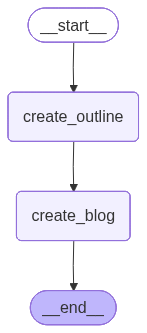

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
initial_state = {'title':'Artificial Intelligence'}
final_state = workflow.invoke(initial_state)
final_state['content'][0]['text']

'# Beyond the Hype: How AI is Actually Changing Our World\n\nYou’ve likely interacted with Artificial Intelligence at least three times before finishing your morning coffee. Maybe it was the face-ID unlock on your phone, the personalized playlist curated by Spotify, or the spam filter that kept your inbox clean overnight. \n\nAI is no longer a futuristic concept reserved for sci-fi movies; it is the invisible engine powering our modern lives. But what exactly is it, and why does it feel like everything changed overnight?\n\n---\n\n### How We Got Here: A Brief History\nThe seeds of AI were sown in the 1950s with Alan Turing’s famous question: *"Can machines think?"* For decades, AI was "rules-based"—programmers had to manually input every "if-this-then-that" instruction. \n\nThe real revolution began with the shift to **Machine Learning** and **Deep Learning**. Instead of being told what to do, computers began learning from data. Today, we are in the era of **Generative AI**. Thanks to 

In [17]:
final_state

{'title': 'Artificial Intelligence',
 'outline': [{'type': 'text',
   'text': 'To create an effective blog post about Artificial Intelligence, you first need to decide on your **angle**. Is it for beginners? Is it about business? Is it about ethics?\n\nBelow is a **comprehensive, versatile outline** that works well for a general "State of AI" or "Introduction to AI" blog post.\n\n---\n\n### Blog Title Ideas:\n*   *Artificial Intelligence: The Future is Already Here*\n*   *Demystifying AI: What You Need to Know in 2024*\n*   *Beyond the Hype: How AI is Actually Changing Our World*\n*   *The AI Revolution: Opportunities, Challenges, and What Comes Next*\n\n---\n\n### Blog Outline\n\n#### I. Introduction\n*   **The Hook:** Start with a relatable scenario (e.g., "You’ve likely interacted with AI three times before finishing your morning coffee").\n*   **Definition:** A simple, jargon-free explanation of what AI is (and what it isn\'t).\n*   **The Thesis:** Briefly state that AI is no longe